
 ============================== -> 第一次运行结果 <- ==============================
“花儿为什么这样红？”这是一个非常美好的问题。它既有着严谨的科学答案，也藏着动人的浪漫情怀。让我从两个角度来为你解答吧：

### 一、 科学的角度：大自然的奇妙魔法

从植物学的角度来看，花儿变红是植物为了生存和繁衍而演化出的智慧：

1. **花青素的“变色魔术”**：花朵之所以呈现红色，主要是因为花瓣细胞中含有**花青素**。花青素对酸碱度非常敏感，当花瓣细胞液呈酸性时，花青素就会显现出鲜艳的红色；如果是碱性，则会偏蓝。
2. **阳光与温度的馈赠**：环境也会影响花儿的颜色。阳光越充足，植物光合作用越强，合成的糖分和花青素就越多，花儿就会红得越娇艳。同时，适当的昼夜温差也有利于色素的积累。
3. **生命的呼唤（吸引传粉者）**：在绿色的大自然中，红色是非常醒目、具有视觉冲击力的颜色。花儿努力“穿”上红色的外衣，是为了吸引蝴蝶、蜜蜂甚至特定的鸟类（如蜂鸟）来采蜜，从而帮助它们传播花粉，繁衍后代。这是生命为了延续而做出的热烈努力。

### 二、 情感与文化的角度：心中的热烈与纯粹

如果你想起的是那首经典的歌曲《花儿为什么这样红》（电影《冰山上的来客》插曲），那么它的答案则充满了人文的温情与诗意：

在那动人的旋律里，花儿之所以这样红，是因为它象征着**青春的热血、纯洁的爱情以及对美好生活的向往**。它红得像燃烧的火焰，代表着人们心中最真挚、最热烈、甚至愿意为之奉献的情感。在文学和艺术中，红花往往是生命力、热情和爱的化身。

***

大自然用化学物质调配出了红色的花朵，而人类用情感赋予了它灵魂。

你今天突然问起这个问题，是偶然在路边看到了一朵特别美丽的红花？是听到了那首怀旧的老歌？还是心里有什么特别的感触和思念呢？如果愿意的话，随时可以和我分享你的心情哦。
 ============================== -> 第二次运行结果 <- ==============================
我们刚才聊了 **“花儿为什么这样红”** 这个美丽又有趣的问题呀。

具体来说，我们从两个角度一起探讨了它：

1. **科学的角度**：我们聊了花朵变红的“幕后功臣”——花青素（在酸性环境下会

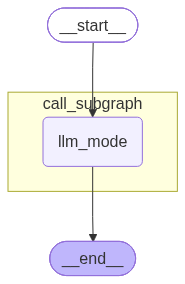

In [1]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.checkpoint.memory import InMemorySaver
from langchain.messages import HumanMessage, SystemMessage
from langchain_deepseek import ChatDeepSeek

from dotenv import load_dotenv
load_dotenv(override=True)

from langchain_qwq import ChatQwen

model = ChatQwen(
    model="qwen3.7-max",
)

# 构建子图
class SubgraphState(MessagesState):
    system_prompt: SystemMessage

def llm_mode(state: SubgraphState) -> SubgraphState:
    system_prompt = state["system_prompt"]
    messages = state["messages"]

    response = model.invoke([system_prompt] + messages)
    return {
        "messages": [response]
    }

builder = StateGraph(state_schema=SubgraphState)
builder.add_node("llm_mode", llm_mode)
builder.add_edge(START, "llm_mode")
builder.add_edge("llm_mode", END)

subgraph = builder.compile(checkpointer=True)

# 构建父图
class ParentState(TypedDict):
    user_input: str
    assistant_response: str

def call_subgraph(state: ParentState) -> ParentState:
    user_input = state["user_input"]

    response = subgraph.invoke(
        {
            "system_prompt": SystemMessage("你是个善解人意的助手"),
            "messages": [HumanMessage(user_input)]
        }
    )

    assistant_response = response["messages"][-1].content

    return {
        "assistant_response": assistant_response
    }

builder = StateGraph(state_schema=ParentState)
builder.add_node("call_subgraph", call_subgraph)
builder.add_edge(START, "call_subgraph")
builder.add_edge("call_subgraph", END)

checkpointer = InMemorySaver()
parent_graph = builder.compile(checkpointer=checkpointer)

config = {"configurable": {"thread_id": "subgraph_stream_test"}}

print("\n", "=" * 30, "-> 第一次运行结果 <-", "=" * 30)
# chunk 形如
# (('call_subgraph',), 'messages', (AIMessageChunk(content='', additional_kwargs={}, response_metadata={'model_provider': 'deepseek'}, id='lc_run--019efd65-c54e-7012-912e-29ff4f84328e', tool_calls=[], invalid_tool_calls=[], tool_call_chunks=[]), {'thread_id': 'subgraph_stream_test', 'langgraph_step': 1, 'langgraph_node': 'llm_mode', 'langgraph_triggers': ('branch:to:llm_mode',), 'langgraph_path': ('__pregel_pull', 'llm_mode'), 'langgraph_checkpoint_ns': 'call_subgraph|llm_mode:55577c3e-22da-877a-c77b-f16bdbcd2c6c', 'checkpoint_ns': 'call_subgraph:9c469391-f094-1c1b-c5d7-6578f1603151', 'ls_provider': 'deepseek', 'ls_model_name': 'deepseek-v4-flash', 'ls_model_type': 'chat', 'ls_temperature': None}))
for chunk in parent_graph.stream(
    {
        "user_input": "花儿为什么这样红？"
    },
    config=config,
    subgraphs=True,
    stream_mode=["messages"]
):
    print(chunk[2][0].content, end="", flush=True)

print("\n", "=" * 30, "-> 第二次运行结果 <-", "=" * 30)
for chunk in parent_graph.stream(
    {
        "user_input": "刚才我们聊了什么？"
    },
    config=config,
    subgraphs=True,
    stream_mode=["messages"]
):
    print(chunk[2][0].content, end="", flush=True)

from IPython.display import display, Image
display(
    Image(
        parent_graph
        .get_graph(xray=True)
        .draw_mermaid_png()
    )
)